In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("login_logs.csv")
df.head()

,timestamp,username,ip_address,status,device,location
0,2026-08-30 11:25:00,sita,45.22.91.12,success,Linux,Lalitpur
1,2026-08-06 00:57:00,finance01,45.22.91.12,success,Windows,Kathmandu
2,2026-08-11 23:07:00,finance01,192.168.1.12,success,Linux,India
3,2026-08-21 19:39:00,admin,192.168.1.10,success,Linux,Pokhara
4,2026-08-08 10:49:00,sachin,192.168.1.11,success,Windows,Kathmandu


In [3]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
df.info()

Rows: 10000
Columns: 6
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   timestamp   10000 non-null  object
 1   username    10000 non-null  object
 2   ip_address  10000 non-null  object
 3   status      10000 non-null  object
 4   device      10000 non-null  object
 5   location    10000 non-null  object
dtypes: object(6)
memory usage: 468.9+ KB


In [4]:
df.columns

Index(['timestamp', 'username', 'ip_address', 'status', 'device', 'location'], dtype='object')

In [5]:
# check the missing value
df.isnull().sum()

timestamp     0
username      0
ip_address    0
status        0
device        0
location      0
dtype: int64

In [6]:
# How many login attempt happened?
total_attempts = len(df)
print("Total Login attempt:", total_attempts)



Total Login attempt: 10000


In [7]:
df["status"].value_counts()

status
success    9019
failed      981
Name: count, dtype: int64

In [8]:
# What percentage of login failed?
failed_login = (df["status"] == "failed").sum()
failure_rate = (failed_login / total_attempts) * 100

print("Failed Login:", failed_login)
print("Failure rate:", round(failure_rate, 2),"%")

Failed Login: 981
Failure rate: 9.81 %


In [9]:
# failed login attempt by uses
failed_by_user = (
    df[df["status"] == "failed"]
    .groupby("username")
    .size()
    .sort_values(ascending=False)
)

failed_by_user

username
hari         120
finance01    117
ram          114
admin        113
hr01         109
manager      109
sales01      103
sita          99
sachin        97
dtype: int64

In [10]:
# find the suspecious user
suspecious_user = failed_by_user[
    failed_by_user > 110
]

suspecious_user

username
hari         120
finance01    117
ram          114
admin        113
dtype: int64

In [11]:
# Failed attemp by IP
failed_by_ip = (
    df[df["status"] == "failed"]
    .groupby("ip_address")
    .size()
    .sort_values(ascending=False)
)

failed_by_ip

ip_address
192.168.1.11    317
192.168.1.12    308
192.168.1.10    262
103.45.22.10     50
45.22.91.12      44
dtype: int64

In [12]:
# find the suspecious IP
suspecious_ip = failed_by_ip[
    failed_by_ip > 200
]
suspecious_ip

ip_address
192.168.1.11    317
192.168.1.12    308
192.168.1.10    262
dtype: int64

In [13]:
# Which IP is targeting the multiple user?
users_per_ip = (
    df[df["status"] == "failed"]
    .groupby("ip_address")["username"]
    .nunique()
    .sort_values(ascending=False)
)

users_per_ip

ip_address
192.168.1.10    9
192.168.1.11    9
192.168.1.12    9
45.22.91.12     9
103.45.22.10    8
Name: username, dtype: int64

In [14]:
# Find the failed logins by location
failed_by_location = (
    df[df["status"] == "failed"]
    .groupby("location")
    .size()
    .sort_values(ascending=False)
)
failed_by_location

location
Lalitpur     209
Kathmandu    202
Pokhara      200
Bhaktapur    191
India        179
dtype: int64

In [17]:
# Failed login by device
failed_by_device = (
    df[df["status"] == "failed"]
    .groupby("device")
    .size()
    .sort_values(ascending=False)
)
failed_by_device

device
iPhone     268
Windows    246
Linux      235
Android    232
dtype: int64

In [18]:
# User level statistic
user_stats = df.groupby("username").agg(
    total_attempt = ("status", "count"),
    failed_attempts = ("status", lambda x: (x == "failed").sum()),
    successful_attempts  = ("status", lambda x: (x == "success").sum()),
    unique_ips = ("ip_address", "nunique"),
    unique_device = ("device", "nunique"),
    unique_location = ("location", "nunique")
)

user_stats

,total_attempt,failed_attempts,successful_attempts,unique_ips,unique_device,unique_location
username,,,,,,
admin,1066,113,953,5,4,5
finance01,1106,117,989,5,4,5
hari,1168,120,1048,5,4,5
hr01,1095,109,986,5,4,5
manager,1140,109,1031,5,4,5
ram,1125,114,1011,5,4,5
sachin,1065,97,968,5,4,5
sales01,1100,103,997,5,4,5
sita,1135,99,1036,5,4,5


In [19]:
# calculate the failure rates for users
user_stats["failure_rate"] = (
    user_stats["failed_attempts"] / user_stats["total_attempt"] * 100
)
user_stats

,total_attempt,failed_attempts,successful_attempts,unique_ips,unique_device,unique_location,failure_rate
username,,,,,,,
admin,1066,113,953,5,4,5,10.600375
finance01,1106,117,989,5,4,5,10.578662
hari,1168,120,1048,5,4,5,10.273973
hr01,1095,109,986,5,4,5,9.954338
manager,1140,109,1031,5,4,5,9.561404
ram,1125,114,1011,5,4,5,10.133333
sachin,1065,97,968,5,4,5,9.107981
sales01,1100,103,997,5,4,5,9.363636
sita,1135,99,1036,5,4,5,8.722467


In [21]:
# Create the risk score
user_stats["risk_score"] = 0

user_stats.loc[
    user_stats["failed_attempts"] >= 5,
    "risk_score"
] += 2

user_stats.loc[
    user_stats["failure_rate"] >= 30,
    "risk_score"
] += 2

user_stats.loc[
    user_stats["unique_ips"] >= 3,
    "risk_score"
] += 2

user_stats.loc[
    user_stats["unique_location"] >= 3,
    "risk_score"
] += 2

In [22]:
# convert score to risk level
def classify_risk(score):

    if score >= 6:
        return "CRITICAL"

    elif score >= 4:
        return "HIGH"

    elif score >= 2:
        return "MEDIUM"

    else:
        return "LOW"


user_stats["risk_level"] = (
    user_stats["risk_score"]
    .apply(classify_risk)
)

user_stats

,total_attempt,failed_attempts,successful_attempts,unique_ips,unique_device,unique_location,failure_rate,risk_score,risk_level
username,,,,,,,,,
admin,1066,113,953,5,4,5,10.600375,6,CRITICAL
finance01,1106,117,989,5,4,5,10.578662,6,CRITICAL
hari,1168,120,1048,5,4,5,10.273973,6,CRITICAL
hr01,1095,109,986,5,4,5,9.954338,6,CRITICAL
manager,1140,109,1031,5,4,5,9.561404,6,CRITICAL
ram,1125,114,1011,5,4,5,10.133333,6,CRITICAL
sachin,1065,97,968,5,4,5,9.107981,6,CRITICAL
sales01,1100,103,997,5,4,5,9.363636,6,CRITICAL
sita,1135,99,1036,5,4,5,8.722467,6,CRITICAL


In [23]:
# show only high risk users
high_risk_users = user_stats[
    user_stats["risk_level"].isin(
        ["HIGH", "CRITICAL"]
    )
]

high_risk_users

,total_attempt,failed_attempts,successful_attempts,unique_ips,unique_device,unique_location,failure_rate,risk_score,risk_level
username,,,,,,,,,
admin,1066,113,953,5,4,5,10.600375,6,CRITICAL
finance01,1106,117,989,5,4,5,10.578662,6,CRITICAL
hari,1168,120,1048,5,4,5,10.273973,6,CRITICAL
hr01,1095,109,986,5,4,5,9.954338,6,CRITICAL
manager,1140,109,1031,5,4,5,9.561404,6,CRITICAL
ram,1125,114,1011,5,4,5,10.133333,6,CRITICAL
sachin,1065,97,968,5,4,5,9.107981,6,CRITICAL
sales01,1100,103,997,5,4,5,9.363636,6,CRITICAL
sita,1135,99,1036,5,4,5,8.722467,6,CRITICAL


Text(0, 0.5, 'failed Attempts')

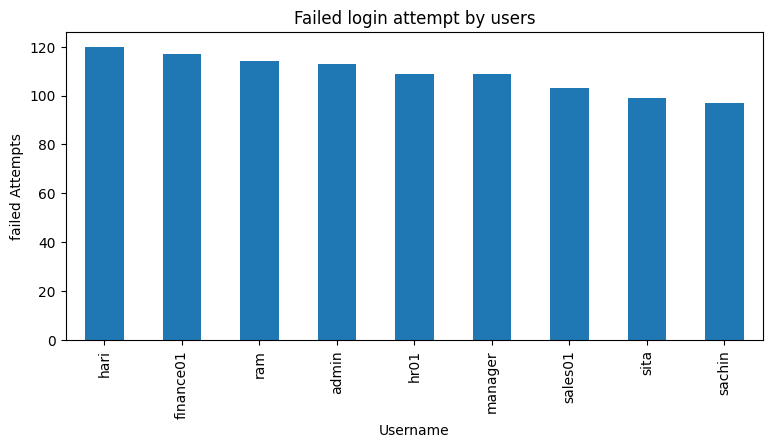

In [30]:
# visulize failed login
failed_by_user.plot(
    kind = "bar",
    figsize = (9, 4)
)

plt.title("Failed login attempt by users")
plt.xlabel("Username")
plt.ylabel("failed Attempts")

Text(0, 0.5, 'Number of users')

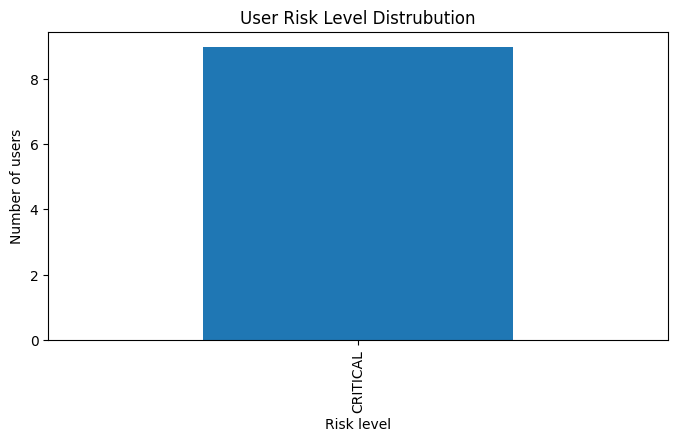

In [31]:
# Risk level distribution
user_stats["risk_level"].value_counts().plot(
    kind = "bar",
    figsize = (8,4)
)

plt.title("User Risk Level Distrubution")
plt.xlabel("Risk level")
plt.ylabel("Number of users")

In [32]:
# export the report
high_risk_users.to_csv("high_risk_users.csv")
print("security report genrated successfully.")

security report genrated successfully.
